**Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt
import seaborn as sns

**Loading Dataset**

In [ ]:
data = pd.read_csv('/content/Admission_Predict.csv')
data.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


**Data Preparation and Cleaning**

In [ ]:
data = data.drop(['Serial No.'], axis=1)

In [ ]:
data = data.rename(columns={'Chance of Admit ': 'Chance of Admit'})

In [ ]:
X = data.drop('Chance of Admit', axis=1)
y = data['Chance of Admit']

**Train and Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Train the Model**

In [ ]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

**Train the model**

In [ ]:
gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

**Predict**

In [ ]:
y_pred = gb_model.predict(X_test)

**Evaluate the Model**

In [ ]:
r2 = r2_score(y_test, y_pred)
print(f"R-squared (R²): {r2:.4f}")

R-squared (R²): 0.7955


**Visualize Feature Importance**

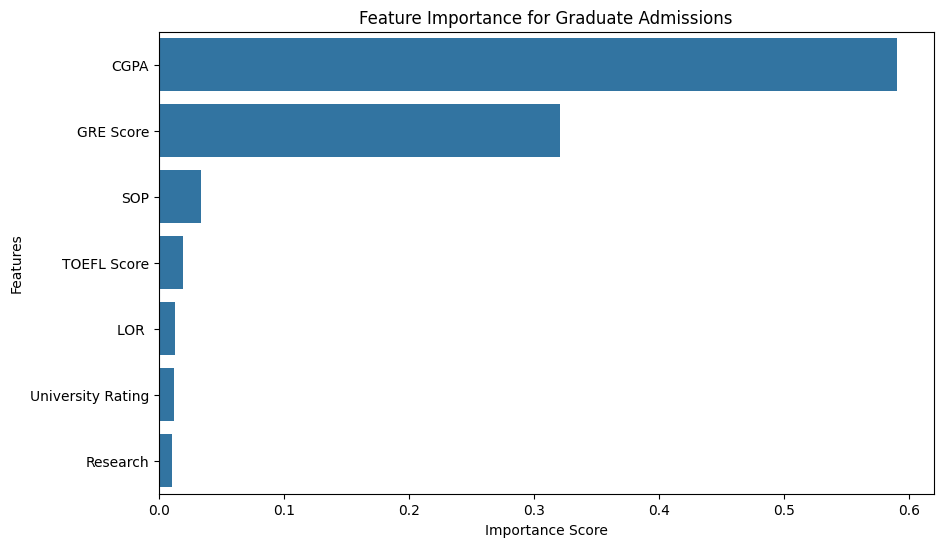

In [ ]:
feature_importance = pd.Series(gb_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance, y=feature_importance.index)
plt.title('Feature Importance for Graduate Admissions')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

**Example Prediction for a New Applicant**

In [ ]:
new_applicant = pd.DataFrame({
    'GRE Score': [330],
    'TOEFL Score': [118],
    'University Rating': [5],
    'SOP': [5.0],
    'LOR ': [5.0],
    'CGPA': [9.5],
    'Research': [1]
})

predicted_chance_sk = gb_model.predict(new_applicant)
print(f"\nPredicted Chance of Admit: {predicted_chance[0]:.4f}")


Predicted Chance of Admit: 0.9361
